# Proyek Analisis Data: E-Commerce Public Dataset 
- **Nama:** Audy Nadira Ramdanti
- **Email:** audynadiraramdanti@gmail.com
- **ID Dicoding:** audy_nadira_ramadanti_zWZ9

## Menentukan Pertanyaan Bisnis

Sebelum melakukan eksplorasi data, terdapat **dua pertanyaan utama** yang akan dianalisis dalam bagian ini:  

1. **Berapa persentase produk dengan skor tinggi (4-5) dibandingkan dengan skor rendah (1-2)?**  
   - **Mengapa ini penting?**  
     - Skor ulasan dapat memengaruhi keputusan pembelian pelanggan.  
     - Memahami distribusi skor membantu dalam mengevaluasi tingkat kepuasan pelanggan terhadap produk.  

2. **Kategori produk apa yang paling diminati pelanggan pada periode tersebut, dan metode pembayaran apa yang paling sering digunakan?**  
   - **Mengapa ini penting?**  
     - Membantu mengidentifikasi tren pembelian berdasarkan **kategori produk**.  
     - Mengetahui metode pembayaran yang paling populer dapat mendukung strategi bisnis, seperti memberikan promosi khusus pada metode yang paling sering digunakan.

## Import Semua Packages/Library yang Digunakan

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

- ✅ **`pandas`** → Mengelola dan memproses data dalam bentuk tabel.  
- ✅ **`numpy`** → Melakukan operasi numerik dan perhitungan matematis.  
- ✅ **`matplotlib.pyplot`** → Membuat grafik untuk analisis data.  
- ✅ **`seaborn`** → Membantu membuat visualisasi data yang lebih menarik dan informatif.  

Dengan mengimpor keempat library ini, kita siap untuk melakukan eksplorasi data lebih lanjut! 🚀  

## Data Wrangling

### Gathering Data

In [2]:
data_customer = pd.read_csv("data/customers_dataset.csv")

data_geolocation = pd.read_csv("data/geolocation_dataset.csv")

data_orders = pd.read_csv("data\orders_dataset.csv")

data_order_item = pd.read_csv("data\order_items_dataset.csv")

data_order_payment = pd.read_csv("data\order_payments_dataset.csv")

data_order_reviews = pd.read_csv("data\order_reviews_dataset.csv")

data_products = pd.read_csv("data\products_dataset.csv")

data_product_category_name =pd.read_csv("data\product_category_name_translation.csv")

data_sellers =pd.read_csv("data\sellers_dataset.csv")

### **Tahap Gathering Data**  
Pada bagian ini, saya melakukan pembacaan beberapa dataset menggunakan `pandas` dan menyimpannya dalam variabel yang sesuai:  

- `data_customer` → Berisi informasi pelanggan  
- `data_geolocation` → Berisi data lokasi geografis  
- `data_orders` → Berisi data pesanan pelanggan  
- `data_order_item` → Berisi detail item dalam pesanan  
- `data_order_payment` → Berisi metode dan jumlah pembayaran dari pesanan  
- `data_order_reviews` → Berisi ulasan pelanggan terhadap pesanan  
- `data_products` → Berisi informasi produk yang dijual  
- `data_product_category_name` → Berisi kategori produk beserta terjemahannya  
- `data_sellers` → Berisi informasi tentang penjual  

Setiap dataset dibaca menggunakan `pd.read_csv("path_dataset")` agar dapat digunakan dalam analisis data.  

### Assessing Data

In [3]:
data_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [4]:
data_customer.isnull().sum()

customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

In [5]:
data_customer[data_customer.duplicated()]

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state


In [6]:
data_geolocation.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_lng              1000163 non-null  float64
 3   geolocation_city             1000163 non-null  object 
 4   geolocation_state            1000163 non-null  object 
dtypes: float64(2), int64(1), object(2)
memory usage: 38.2+ MB


In [7]:
data_geolocation.isnull().sum()

geolocation_zip_code_prefix    0
geolocation_lat                0
geolocation_lng                0
geolocation_city               0
geolocation_state              0
dtype: int64

In [8]:
data_geolocation[data_geolocation.duplicated()]

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
15,1046,-23.546081,-46.644820,sao paulo,SP
44,1046,-23.546081,-46.644820,sao paulo,SP
65,1046,-23.546081,-46.644820,sao paulo,SP
66,1009,-23.546935,-46.636588,sao paulo,SP
67,1046,-23.546081,-46.644820,sao paulo,SP
...,...,...,...,...,...
1000153,99970,-28.343273,-51.873734,ciriaco,RS
1000154,99950,-28.070493,-52.011342,tapejara,RS
1000159,99900,-27.877125,-52.224882,getulio vargas,RS
1000160,99950,-28.071855,-52.014716,tapejara,RS


In [9]:
data_orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [10]:
data_orders.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [11]:
data_orders[data_orders.duplicated()]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date


In [12]:
data_order_item.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [13]:
data_order_item.isnull().sum()

order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

In [14]:
data_order_item[data_order_item.duplicated()]

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value


In [15]:
data_order_reviews.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB


In [16]:
data_order_reviews.isnull().sum()

review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64

In [17]:
data_order_reviews[data_order_reviews.duplicated()]

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp


In [18]:
data_order_payment.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


In [19]:
data_order_payment.isnull().sum()

order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

In [20]:
data_order_payment[data_order_payment.duplicated()]

,order_id,payment_sequential,payment_type,payment_installments,payment_value


In [21]:
data_products.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


In [22]:
data_products.isnull().sum()

product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

In [23]:
data_products[data_products.duplicated()]

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm


In [24]:
data_product_category_name.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   product_category_name          71 non-null     object
 1   product_category_name_english  71 non-null     object
dtypes: object(2)
memory usage: 1.2+ KB


In [25]:
data_product_category_name.isnull().sum()

product_category_name            0
product_category_name_english    0
dtype: int64

In [26]:
data_product_category_name[data_product_category_name.duplicated()]

,product_category_name,product_category_name_english


In [27]:
data_sellers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   seller_id               3095 non-null   object
 1   seller_zip_code_prefix  3095 non-null   int64 
 2   seller_city             3095 non-null   object
 3   seller_state            3095 non-null   object
dtypes: int64(1), object(3)
memory usage: 96.8+ KB


In [28]:
data_sellers.isnull().sum()

seller_id                 0
seller_zip_code_prefix    0
seller_city               0
seller_state              0
dtype: int64

In [29]:
data_sellers[data_sellers.duplicated()]

,seller_id,seller_zip_code_prefix,seller_city,seller_state


Sebelum melakukan analisis lebih lanjut, langkah awal yang dilakukan adalah memahami struktur dataset dan mengevaluasi kualitas data menggunakan metode berikut:  

---

## **1. Memeriksa Struktur Data**  
- **Kode yang digunakan**:  
  ```python
  data_x.info()
  ```
- **Tujuan**:  
  - Menampilkan **jumlah total baris dan kolom** dalam dataset.  
  - Melihat **tipe data** di setiap kolom (`object`, `int64`, `float64`).  
  - Memeriksa **jumlah nilai non-null** untuk mengetahui apakah ada data yang hilang (missing values).  

Namun, hasil yang ditampilkan di bawah ini bukan berasal dari `.info()`, melainkan dari `.isnull().sum()` yang bertujuan untuk mengecek jumlah nilai yang hilang di setiap kolom.  

---

## **2. Memeriksa Nilai yang Hilang (Missing Values)**  
- **Kode yang digunakan**:  
  ```python
  data_x.isnull().sum()
  ```
- **Tujuan**:  
  - Mengidentifikasi kolom yang memiliki nilai yang hilang.  
  - Mengetahui seberapa banyak nilai yang hilang di setiap kolom.  

### **Hasil Temuan Missing Values**  
| **Dataset**          | **Kolom dengan Missing Values**                         | **Jumlah Missing Values** |
|----------------------|-------------------------------------------------------|--------------------------|
| `data_orders`       | `order_approved_at`                                   | 160                      |
|                      | `order_delivered_carrier_date`                        | 1,783                    |
|                      | `order_delivered_customer_date`                       | 2,965                    |
| `data_order_reviews`| `review_comment_title`                                | 87,656                   |
|                      | `review_comment_message`                              | 58,247                   |
| `data_products`     | `product_category_name`, `product_name_length`, `product_description_length`, `product_photos_qty` | 610                      |
|                      | `product_weight_g`, `product_length_cm`, `product_height_cm`, `product_width_cm` | 2                        |

---

## **3. Memeriksa Duplikasi Data**  
- **Kode yang digunakan**:  
  ```python
  data_x[data_x.duplicated()]
  ```
- **Tujuan**:  
  - Mengetahui apakah ada **baris data yang duplikat** dalam dataset.  
  - Data duplikat dapat menyebabkan bias dalam analisis sehingga perlu dibersihkan.  

### **Hasil Temuan Duplikasi**  
- Dataset `data_geolocation` memiliki kemungkinan **banyak data duplikat** yang perlu ditangani dalam proses **Data Cleaning**.  

 

### Cleaning Data

Setelah melakukan tahap **Assessing Data**, ditemukan beberapa masalah seperti **duplikasi data** dan **missing values** dalam jumlah besar. Oleh karena itu, langkah berikutnya adalah **membersihkan data** agar siap untuk dianalisis.  

In [30]:
#Menghapus duplicate pada data_geolocation

data_geolocation = data_geolocation.drop_duplicates()

data_geolocation[data_geolocation.duplicated()]


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state


## **1. Menghapus Data Duplikat**  
- **Kode yang digunakan:**  
  ```python
  data_geolocation = data_geolocation.drop_duplicates()
  data_geolocation[data_geolocation.duplicated()]
  ```
- **Penjelasan:**  
  - `drop_duplicates()` digunakan untuk menghapus semua baris yang memiliki nilai **duplikat** dalam dataset `data_geolocation`.  
  - Setelah proses penghapusan, dilakukan pengecekan kembali dengan `data_geolocation[data_geolocation.duplicated()]` untuk memastikan tidak ada data duplikat yang tersisa. 

In [31]:
#Memberikan treshold untuk mengukur apakah missing value yang terjadi diatas 50%
threshold = 0.5
data_order_reviews = data_order_reviews.dropna(axis=1, thresh=int(threshold * len(data_order_reviews)))

data_order_reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_creation_date     99224 non-null  object
 4   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


## **2. Menangani Missing Values dengan Threshold (50%)**  
- **Kode yang digunakan:**  
  ```python
  threshold = 0.5
  data_order_reviews = data_order_reviews.dropna(axis=1, thresh=int(threshold * len(data_order_reviews)))
  data_order_reviews.info()
  ```
- **Penjelasan:**  
  - Menggunakan **threshold 50%**, artinya kolom dengan **lebih dari 50% missing values** akan **dihapus** dari dataset `data_order_reviews`.  
  - Ini dilakukan karena beberapa kolom memiliki terlalu banyak data yang hilang, sehingga dianggap **tidak signifikan untuk analisis selanjutnya**.  
  - Setelah penghapusan, `info()` digunakan untuk mengecek struktur dataset terbaru.  

In [32]:
# Mengganti missing values pada kolom kategori dan deskripsi dengan "UNKNOWN"
cols_to_unknown = ['product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty']
data_products[cols_to_unknown] = data_products[cols_to_unknown].fillna("UNKNOWN")

# Mengganti missing values pada kolom numerik dengan mean
cols_to_mean = ['product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']
data_products[cols_to_mean] = data_products[cols_to_mean].fillna(data_products[cols_to_mean].mean())

data_products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32951 non-null  object 
 2   product_name_lenght         32951 non-null  object 
 3   product_description_lenght  32951 non-null  object 
 4   product_photos_qty          32951 non-null  object 
 5   product_weight_g            32951 non-null  float64
 6   product_length_cm           32951 non-null  float64
 7   product_height_cm           32951 non-null  float64
 8   product_width_cm            32951 non-null  float64
dtypes: float64(4), object(5)
memory usage: 2.3+ MB


## **3. Mengisi Missing Values pada `data_products`**  
- **Kode yang digunakan:**  
  ```python
  # Mengganti missing values pada kolom kategori dan deskripsi dengan "UNKNOWN"
  cols_to_unknown = ['product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty']
  data_products[cols_to_unknown] = data_products[cols_to_unknown].fillna("UNKNOWN")

  # Mengganti missing values pada kolom numerik dengan mean
  cols_to_mean = ['product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']
  data_products[cols_to_mean] = data_products[cols_to_mean].fillna(data_products[cols_to_mean].mean())

  data_products.info()
  ```
- **Penjelasan:**  
  - Kolom yang bersifat **kategori atau teks** (`object`) seperti `product_category_name`, `product_name_lenght`, dll., diisi dengan `"UNKNOWN"` agar tetap dapat digunakan dalam analisis.  
  - Kolom yang bersifat **numerik** (`float64` atau `int64`) seperti `product_weight_g`, `product_length_cm`, dll., diisi dengan **mean (rata-rata)**.  
  - Metode **mean** dipilih karena jumlah missing values dalam kolom numerik **sangat kecil (hanya 2 data)** sehingga tidak akan menyebabkan bias besar dalam analisis.  

In [33]:
cols_to_unknown = ['order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date']
data_orders[cols_to_unknown] = data_orders[cols_to_unknown].fillna("UNKNOWN")

data_orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99441 non-null  object
 5   order_delivered_carrier_date   99441 non-null  object
 6   order_delivered_customer_date  99441 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


## **4. Mengisi Missing Values pada `data_orders`**  
- **Kode yang digunakan:**  
  ```python
  cols_to_unknown = ['order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date']
  data_orders[cols_to_unknown] = data_orders[cols_to_unknown].fillna("UNKNOWN")

  data_orders.info()
  ```
- **Penjelasan:**  
  - Semua kolom yang memiliki missing values dalam dataset `data_orders` adalah **tipe data object (teks)**.  
  - Oleh karena itu, nilai yang hilang diganti dengan `"UNKNOWN"` agar tetap bisa digunakan dalam analisis tanpa kehilangan informasi penting.  


## Exploratory Data Analysis (EDA)

### Explore Dataset

Berdasarkan proses **Assessing Data**, saya melihat bahwa dataset yang digunakan memiliki struktur yang sama seperti pada gambar di bawah ini:

![Struktur Dataset](img\relasi_data.png)

Dataset ini terdiri dari beberapa tabel yang saling terhubung melalui **relasi kunci utama dan kunci asing**, seperti *order_id*, *customer_id*, *product_id*, dan *seller_id*.  

Untuk memudahkan eksplorasi data dan analisis lebih lanjut, langkah selanjutnya adalah **menggabungkan semua dataset yang tersedia**. Dengan menggabungkan dataset ini, kita dapat memperoleh informasi yang lebih lengkap dan menyeluruh, seperti hubungan antara pesanan, pelanggan, metode pembayaran, kategori produk, serta ulasan pelanggan.  

Proses ini akan membantu dalam menemukan pola, tren, serta wawasan bisnis yang lebih akurat dari data yang tersedia.


In [34]:
# Merge orders dengan order_items
data = data_orders.merge(data_order_item, on="order_id", how="inner")

# Merge dengan products
data = data.merge(data_products, on="product_id", how="inner")

# Merge dengan payments
data = data.merge(data_order_payment, on="order_id", how="inner")

# Merge dengan reviews
data = data.merge(data_order_reviews, on="order_id", how="inner")

# Merge dengan sellers
data = data.merge(data_sellers, on="seller_id", how="inner")

# Merge dengan customers
data = data.merge(data_customer, on="customer_id", how="inner")


data["zip_code_prefix"] = data["customer_zip_code_prefix"].fillna(data["seller_zip_code_prefix"])

data_geolocation.rename(columns={"geolocation_zip_code_prefix": "zip_code_prefix"}, inplace=True)

# Merge dengan geolocation berdasarkan zip_code_prefix dari customers dan sellers
data = data.merge(data_geolocation, on="zip_code_prefix", how="inner")

data.drop(columns=["customer_zip_code_prefix", "seller_zip_code_prefix"], inplace=True)

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12264705 entries, 0 to 12264704
Data columns (total 40 columns):
 #   Column                         Dtype  
---  ------                         -----  
 0   order_id                       object 
 1   customer_id                    object 
 2   order_status                   object 
 3   order_purchase_timestamp       object 
 4   order_approved_at              object 
 5   order_delivered_carrier_date   object 
 6   order_delivered_customer_date  object 
 7   order_estimated_delivery_date  object 
 8   order_item_id                  int64  
 9   product_id                     object 
 10  seller_id                      object 
 11  shipping_limit_date            object 
 12  price                          float64
 13  freight_value                  float64
 14  product_category_name          object 
 15  product_name_lenght            object 
 16  product_description_lenght     object 
 17  product_photos_qty             object 
 18  

Untuk memudahkan eksplorasi dataset, seluruh dataset dari berbagai sumber digabungkan menjadi satu dataset utama menggunakan **inner join**. **Metode `inner join` dipilih** karena hanya akan mengambil data yang memiliki referensi yang sama di kedua tabel yang digabungkan. Dengan cara ini, kita dapat memastikan bahwa data yang digunakan relevan dan tidak ada entitas yang tidak memiliki pasangan dalam tabel lain.  

---

#### **1. Menggabungkan Seluruh Dataset**  
- **Kode yang digunakan:**  
  ```python
  # Merge orders dengan order_items
  data = data_orders.merge(data_order_item, on="order_id", how="inner")

  # Merge dengan products
  data = data.merge(data_products, on="product_id", how="inner")

  # Merge dengan payments
  data = data.merge(data_order_payment, on="order_id", how="inner")

  # Merge dengan reviews
  data = data.merge(data_order_reviews, on="order_id", how="inner")

  # Merge dengan sellers
  data = data.merge(data_sellers, on="seller_id", how="inner")

  # Merge dengan customers
  data = data.merge(data_customer, on="customer_id", how="inner")
  ```
- **Mengapa Menggunakan `inner join`?**  
  - **Menghindari data yang tidak lengkap** → Hanya order yang memiliki **informasi lengkap** (produk, pembayaran, ulasan, dll.) yang akan dipertahankan.  
  - **Mencegah data yang tidak relevan** → Jika suatu transaksi tidak memiliki pasangan di tabel lain, berarti transaksi tersebut tidak memiliki informasi yang cukup untuk dianalisis.  
  - **Mengoptimalkan analisis** → Hanya data yang benar-benar digunakan yang tersimpan, mengurangi noise dalam analisis.  

  ---


  #### **2. Menyesuaikan Data Geolocation**  
- **Kode yang digunakan:**  
  ```python
  data["zip_code_prefix"] = data["customer_zip_code_prefix"].fillna(data["seller_zip_code_prefix"])
  data_geolocation.rename(columns={"geolocation_zip_code_prefix": "zip_code_prefix"}, inplace=True)
  data = data.merge(data_geolocation, on="zip_code_prefix", how="inner")
  data.drop(columns=["customer_zip_code_prefix", "seller_zip_code_prefix"], inplace=True)
  ```
- **Penjelasan:**  
  - Jika `customer_zip_code_prefix` kosong, diisi dengan `seller_zip_code_prefix`.  
  - Nama kolom `geolocation_zip_code_prefix` diubah agar bisa digabungkan dengan dataset utama.  
  - **Inner join** digunakan agar hanya data yang memiliki referensi lokasi yang dipertahankan.  

In [35]:
data.isna().sum()

order_id                         0
customer_id                      0
order_status                     0
order_purchase_timestamp         0
order_approved_at                0
order_delivered_carrier_date     0
order_delivered_customer_date    0
order_estimated_delivery_date    0
order_item_id                    0
product_id                       0
seller_id                        0
shipping_limit_date              0
price                            0
freight_value                    0
product_category_name            0
product_name_lenght              0
product_description_lenght       0
product_photos_qty               0
product_weight_g                 0
product_length_cm                0
product_height_cm                0
product_width_cm                 0
payment_sequential               0
payment_type                     0
payment_installments             0
payment_value                    0
review_id                        0
review_score                     0
review_creation_date

Setelah data digabungkan, saya menggunakan `data.isna().sum()` untuk mengetahui apakah masih terdapat **missing values** (nilai yang hilang) dalam dataset.  

Fungsi `isna().sum()` akan menghitung jumlah nilai **NaN (Not a Number) atau NaT (Not a Time)** di setiap kolom, sehingga saya dapat mengidentifikasi kolom mana yang memiliki data yang tidak lengkap.  

Jika masih terdapat missing values, langkah selanjutnya adalah menangani data yang hilang, baik dengan **menghapusnya**, **mengisi dengan nilai tertentu (imputasi)**, atau **menggunakan teknik interpolasi** tergantung pada kebutuhan analisis dan jenis data yang digunakan.

In [36]:
customer_behavior = data.groupby("customer_unique_id").agg({
    "order_id": "count",             # Total pesanan
    "payment_value": ["sum", "mean"], # Total belanja & rata-rata belanja per pesanan
    "review_score": "mean"           # Rata-rata review
}).reset_index()

customer_behavior.columns = ["customer_unique_id", "total_orders", "total_spent", "avg_spent_per_order", "avg_review_score"]

print(customer_behavior.head())


                 customer_unique_id  total_orders  total_spent  \
0  0000366f3b9a7992bf8c76cfdf3221e2            51      7236.90   
1  0000b849f77a49e4a4ce2b2a4ca5be3f            60      1631.40   
2  0000f46a3911fa3c0805444483337064            78      6725.16   
3  0000f6ccb0745a6a4b88665a16c9f078            28      1221.36   
4  0004aac84e0df4da2b147fca70cf8255           102     20082.78   

   avg_spent_per_order  avg_review_score  
0               141.90               5.0  
1                27.19               4.0  
2                86.22               3.0  
3                43.62               4.0  
4               196.89               5.0  


Pada tahap eksplorasi data ini, saya melakukan grouping terhadap kolom **customer_unique_id** untuk mengelompokkan data berdasarkan masing-masing pelanggan unik. Langkah ini memungkinkan kita untuk mengamati dan menganalisis pola perilaku setiap pelanggan secara individual. Berikut penjelasan dari masing-masing metrik yang dihitung:

- **Total Orders**:  
  Dengan menghitung jumlah **order_id** per pelanggan, kita bisa mengetahui berapa banyak transaksi yang dilakukan oleh setiap pelanggan. Hal ini membantu mengidentifikasi pelanggan yang aktif dan loyal.

- **Total Spent**:  
  Agregasi **payment_value** dengan fungsi **sum** memberikan total belanja yang telah dilakukan oleh pelanggan tersebut. Informasi ini berguna untuk mengetahui pelanggan dengan kontribusi pengeluaran terbesar.

- **Average Spent per Order**:  
  Menggunakan fungsi **mean** pada **payment_value** membantu kita memahami rata-rata pengeluaran dalam setiap transaksi. Data ini memberikan gambaran tentang seberapa besar pembelanjaan rata-rata yang dilakukan per pesanan oleh pelanggan.

- **Average Review Score**:  
  Agregasi **review_score** dengan fungsi **mean** mengindikasikan tingkat kepuasan pelanggan terhadap produk atau layanan. Nilai rata-rata ini bisa digunakan untuk mengevaluasi kualitas pengalaman pelanggan.

Secara keseluruhan, grouping ini berfungsi untuk mengungkap insight mendalam mengenai perilaku pelanggan, seperti seberapa sering mereka berbelanja, total pengeluaran mereka, dan tingkat kepuasan yang mereka berikan melalui ulasan. Data tersebut sangat berguna untuk strategi pemasaran, segmentasi pelanggan, dan peningkatan layanan berdasarkan perilaku dan preferensi pelanggan.

In [37]:
# Konversi kolom tanggal dengan mengabaikan error (nilai invalid akan jadi NaT)
data["order_purchase_timestamp"] = pd.to_datetime(data["order_purchase_timestamp"], errors='coerce')
data["order_delivered_customer_date"] = pd.to_datetime(data["order_delivered_customer_date"], errors='coerce')

# Menghitung durasi pengiriman (dalam hari)
data["delivery_time"] = (data["order_delivered_customer_date"] - data["order_purchase_timestamp"]).dt.days

# Jika perlu, cek berapa banyak nilai NaT di delivery_time
print("Jumlah nilai NaT di delivery_time:", data["delivery_time"].isna().sum())

# Analisis performa seller, misal:
seller_performance = data.groupby("seller_id").agg({
    "order_id": "count",           # Total pesanan
    "price": "sum",                # Total pendapatan
    "delivery_time": "mean",       # Rata-rata waktu pengiriman
    "review_score": "mean"         # Rata-rata skor ulasan
}).reset_index()

seller_performance.columns = ["seller_id", "total_orders", "total_revenue", "avg_delivery_time", "avg_review_score"]

print(seller_performance.head())

Jumlah nilai NaT di delivery_time: 247369
                          seller_id  total_orders  total_revenue  \
0  0015a82c2db000af6aaaf3ae2ecb0532           700      626500.00   
1  001cca7ae9ae17fb1caed9dfb1094831         27345     2861932.71   
2  001e6ad469a905060d959994f1b41e4f            50       12500.00   
3  002100f778ceb8431b7a1020ff7ab48f          6293      139793.70   
4  003554e2dce176b5555353e4f3555ac8            88       10560.00   

   avg_delivery_time  avg_review_score  
0          11.468571          4.600000  
1          11.998779          4.025526  
2                NaN          1.000000  
3          14.004177          4.077546  
4           4.000000          5.000000  


Selanjutnya, saya melakukan analisis performa seller berdasarkan data transaksi. Berikut penjelasan langkah demi langkah dari kode di atas:

1. **Konversi Format Tanggal:**  
   - Saya mengonversi kolom **order_purchase_timestamp** dan **order_delivered_customer_date** ke dalam format datetime menggunakan `pd.to_datetime()` dengan parameter `errors='coerce'`.  
   - Parameter `errors='coerce'` memastikan bahwa jika terdapat nilai yang tidak sesuai (misalnya, nilai seperti "UNKNOWN"), maka akan dikonversi menjadi `NaT` (Not a Time), sehingga tidak mengganggu perhitungan waktu.

2. **Menghitung Durasi Pengiriman:**  
   - Setelah data tanggal telah dikonversi, saya menghitung durasi pengiriman dengan mengurangkan **order_purchase_timestamp** dari **order_delivered_customer_date**.  
   - Hasil pengurangan ini dikonversi menjadi hari dengan menggunakan `.dt.days` dan disimpan dalam kolom baru bernama **delivery_time**.  
   - Langkah ini memungkinkan kita untuk mengetahui berapa lama waktu yang dibutuhkan untuk mengirimkan pesanan ke pelanggan.

3. **Validasi Data Tanggal:**  
   - Saya juga memeriksa jumlah nilai `NaT` pada kolom **delivery_time** dengan `data["delivery_time"].isna().sum()`.  
   - Informasi ini berguna untuk mengetahui seberapa banyak data tanggal yang tidak valid, yang mungkin perlu penanganan lebih lanjut dalam analisis.

4. **Analisis Performa Seller:**  
   - Selanjutnya, data dikelompokkan berdasarkan **seller_id** menggunakan `groupby` untuk menghitung beberapa metrik penting:
     - **Total Orders:** Menggunakan `count` pada **order_id** untuk mengetahui jumlah pesanan yang ditangani oleh setiap seller.
     - **Total Revenue:** Menggunakan `sum` pada **price** untuk menghitung total pendapatan yang dihasilkan oleh masing-masing seller.
     - **Average Delivery Time:** Menggunakan `mean` pada kolom **delivery_time** untuk mengetahui rata-rata waktu pengiriman dari setiap seller.
     - **Average Review Score:** Menggunakan `mean` pada **review_score** untuk mendapatkan rata-rata skor ulasan yang diterima seller.
     
   - Setelah agregasi, hasilnya di-reset index dan kolom diberi nama ulang agar lebih mudah dipahami.

5. **Tujuan Analisis:**  
   - Dengan analisis ini, kita dapat mengidentifikasi seller dengan performa terbaik maupun yang perlu diperbaiki.  
   - Misalnya, seller dengan **total orders** tinggi dan **total revenue** besar bisa jadi merupakan seller yang paling populer, sedangkan **avg_delivery_time** dan **avg_review_score** memberikan gambaran tentang efisiensi pengiriman dan kepuasan pelanggan.  
   - Informasi ini sangat berguna untuk perbaikan strategi operasional dan peningkatan kualitas layanan.

Kode di atas membantu memberikan insight mendalam mengenai kinerja masing-masing seller, yang nantinya dapat digunakan sebagai dasar untuk pengambilan keputusan dalam meningkatkan performa dan kualitas pelayanan.

In [38]:
unique_payment_types = data['payment_type'].unique()
print("Nilai unik dari payment_type:", unique_payment_types)

Nilai unik dari payment_type: ['credit_card' 'voucher' 'boleto' 'debit_card']


Terakhir, saya melakukan ekstraksi nilai unik dari kolom **payment_type** dengan menggunakan method `unique()`. Langkah ini bertujuan untuk mengetahui semua jenis metode pembayaran yang terdapat dalam dataset, sehingga dapat memberikan gambaran yang lebih lengkap mengenai preferensi dan variasi metode pembayaran yang digunakan oleh pelanggan. Informasi ini sangat berguna untuk analisis segmentasi pelanggan dan membantu dalam pengambilan keputusan strategis terkait sistem pembayaran.

In [39]:
data_sample = data.sample(n=10000, random_state=42)

# Menentukan folder tujuan
folder = "dashboard"

# Jika folder belum ada, buat foldernya terlebih dahulu
import os
if not os.path.exists(folder):
    os.makedirs(folder)

# Menyimpan file CSV di dalam folder "dashboard"
data_sample.to_csv(os.path.join(folder, "main_data.csv"), index=False)


Sebelum memasuki tahap visualisasi, saya terlebih dahulu mengambil **sampel data sebanyak 10.000 baris** dari data utama menggunakan fungsi `sample()` dengan parameter `random_state=42` untuk memastikan hasil pengambilan sampel bersifat konsisten. Sampel data ini kemudian saya ekspor ke dalam **file CSV** agar lebih mudah diakses dalam proses **pembuatan dashboard menggunakan Streamlit Cloud**.  

Dengan menyimpan data dalam format CSV, saya dapat dengan efisien **mengelola, memuat, dan memproses data** di dalam aplikasi Streamlit tanpa perlu memuat keseluruhan dataset atau melakukan pengambilan sampel ulang setiap kali aplikasi dijalankan.

Dalam kode di atas, saya menentukan **folder tujuan penyimpanan** bernama **"dashboard"**. Jika folder tersebut **belum tersedia**, maka folder akan dibuat terlebih dahulu menggunakan `os.makedirs()`. Setelah folder tersedia, data sampel diekspor ke dalam file **"main_data.csv"** menggunakan metode `to_csv()`, dengan path yang diarahkan ke dalam folder "dashboard".

Dengan pendekatan ini, data sampel yang telah disiapkan akan tersimpan dengan rapi dan siap digunakan dalam proses visualisasi dan pengembangan dashboard ke depannya. 🚀

## Visualization & Explanatory Analysis

### Pertanyaan 1:

In [40]:
# Mengelompokkan berdasarkan review_score dan jumlahkan order_item_id (jumlah barang terjual)
sales_by_review = data.groupby("review_score")["order_item_id"].sum().reset_index()

# Memisahkan kategori skor tinggi (4-5) dan skor rendah (1-2)
high_score_sales = sales_by_review[sales_by_review["review_score"].isin([4, 5])]["order_item_id"].sum()
low_score_sales = sales_by_review[sales_by_review["review_score"].isin([1, 2])]["order_item_id"].sum()

print(f"Jumlah barang terjual dengan skor tinggi (4-5): {high_score_sales}")
print(f"Jumlah barang terjual dengan skor rendah (1-2): {low_score_sales}")


Jumlah barang terjual dengan skor tinggi (4-5): 10659278
Jumlah barang terjual dengan skor rendah (1-2): 2854572


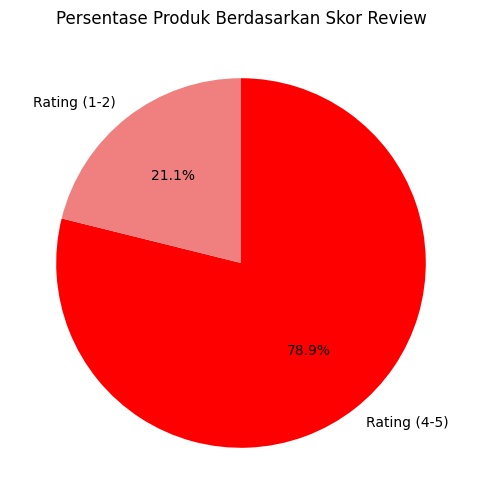

In [41]:
# Tentukan warna: yang lebih besar lebih terang, yang lebih kecil lebih pudar
if high_score_sales > low_score_sales:
    colors = ['red', 'lightcoral']  # 'red' untuk skor tinggi, 'lightcoral' (merah muda) untuk skor rendah
else:
    colors = ['lightcoral', 'red']

labels = ['Rating (4-5)', 'Rating (1-2)']
sizes = [high_score_sales, low_score_sales]

plt.figure(figsize=(6, 6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', colors=colors, startangle=90, counterclock=False)
plt.title("Persentase Produk Berdasarkan Skor Review")
plt.show()

Dari hasil analisis yang ditampilkan dalam grafik, dapat dilihat bahwa **sekitar 78.9% produk memiliki skor review tinggi (4-5)**, sedangkan **21.1% produk memiliki skor review rendah (1-2)**. Hal ini menunjukkan bahwa **produk dengan review yang lebih baik cenderung lebih diminati oleh pelanggan**, sekaligus menegaskan bahwa **review score berperan penting dalam keputusan pembelian**. Dengan kata lain, semakin baik ulasan yang diberikan oleh pelanggan sebelumnya, semakin tinggi kemungkinan produk tersebut akan dibeli oleh pelanggan baru.

Informasi ini menjadi penting karena **mengetahui distribusi skor dapat membantu memahami tingkat kepuasan pelanggan terhadap produk**. Jika mayoritas produk memiliki skor tinggi, berarti kualitas produk dan layanan yang diberikan telah sesuai dengan harapan pelanggan. Sebaliknya, jika banyak produk memiliki skor rendah, maka ada **peluang perbaikan** dari segi kualitas produk, layanan pelanggan, maupun pengiriman.

Selain itu, dari sudut pandang bisnis, pemahaman ini bisa digunakan untuk **strategi pemasaran**, seperti menonjolkan produk dengan skor tinggi dalam promosi atau memberikan insentif bagi pelanggan untuk memberikan review positif. Hal ini juga dapat menjadi indikator bagi penjual untuk melakukan peningkatan kualitas pada produk dengan skor rendah guna meningkatkan daya tariknya di pasar.

### Pertanyaan 2:

C:\Users\FX506\AppData\Local\Temp\ipykernel_36500\1467214427.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_categories.values, y=top_categories.index, palette=colors)


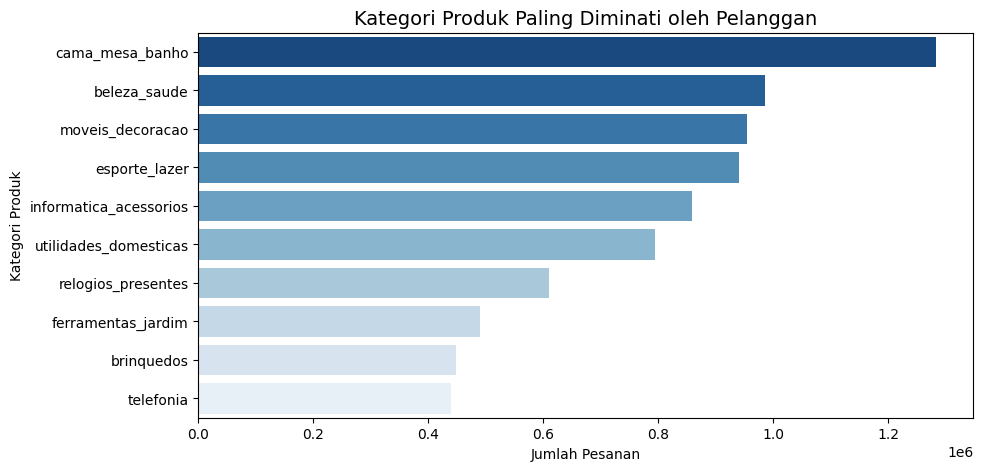

In [42]:
# Hitung jumlah pesanan per kategori produk
top_categories = data['product_category_name'].value_counts().head(10)

# Buat warna dengan gradasi dari palet 'Blues'
colors = sns.color_palette("Blues", n_colors=len(top_categories))[::-1]


# Plot kategori produk
plt.figure(figsize=(10, 5))
sns.barplot(x=top_categories.values, y=top_categories.index, palette=colors)

# Tambahkan judul dan label
plt.title("Kategori Produk Paling Diminati oleh Pelanggan", fontsize=14)
plt.xlabel("Jumlah Pesanan")
plt.ylabel("Kategori Produk")

plt.show()


### **Kategori Produk yang Paling Diminati oleh Pelanggan**  

Pada saat itu, kategori produk yang paling diminati oleh pelanggan adalah **cama_mesa_banho** (produk perlengkapan tempat tidur, meja, dan kamar mandi), yang memiliki jumlah pesanan tertinggi dibandingkan dengan kategori lainnya. Selain itu, kategori **beleza_saude** (produk kecantikan dan kesehatan) serta **moveis_decoracao** (perabot dan dekorasi rumah) juga termasuk dalam daftar produk yang banyak diminati. Kategori lainnya yang cukup populer adalah **esporte_lazer** (olahraga dan rekreasi), **informatica_acessorios** (aksesori komputer), serta **utilidades_domesticas** (peralatan rumah tangga).  

Karena kategori produk dalam dataset sangat banyak, saya hanya mengambil **10 kategori teratas** berdasarkan jumlah pesanan untuk mendapatkan gambaran yang lebih jelas mengenai tren belanja pelanggan. Dari hasil analisis ini, terlihat bahwa pelanggan cenderung melakukan pembelian untuk kebutuhan rumah tangga, kecantikan, serta teknologi dan hiburan.  

Informasi ini dapat membantu bisnis dalam merancang strategi pemasaran dan mengelola stok barang dengan lebih efektif, terutama untuk produk-produk yang paling sering dibeli pelanggan.

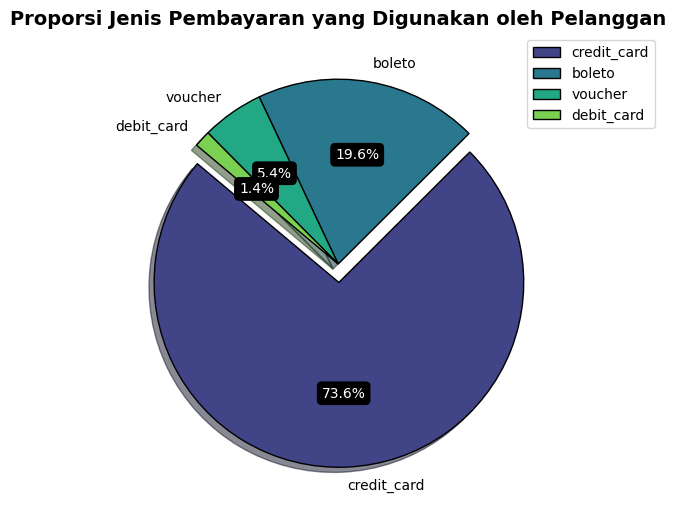

In [43]:
# Hitung jumlah transaksi per jenis pembayaran
payment_counts = data['payment_type'].value_counts()

# Gunakan palet warna bergradasi (contoh: "viridis", bisa diganti misalnya "magma", "plasma", dll.)
colors = sns.color_palette("viridis", len(payment_counts))

# Atur efek explode untuk menonjolkan metode pembayaran paling populer
explode = [0.1 if i == 0 else 0 for i in range(len(payment_counts))]

# Buat pie chart
plt.figure(figsize=(8, 6))
wedges, texts, autotexts = plt.pie(
    payment_counts, labels=payment_counts.index, autopct='%1.1f%%',
    colors=colors, startangle=140, explode=explode, shadow=True, wedgeprops={'edgecolor': 'black'}
)

# Ubah format teks persentase agar memiliki background hitam seperti contoh
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_bbox(dict(facecolor='black', edgecolor='black', boxstyle='round,pad=0.3'))

# Tambahkan judul
plt.title("Proporsi Jenis Pembayaran yang Digunakan oleh Pelanggan", fontsize=14, fontweight='bold')

# Tambahkan legenda di samping
plt.legend(payment_counts.index, loc="upper right", bbox_to_anchor=(1.2, 1))

# Tampilkan plot
plt.show()


### **Jenis Pembayaran yang Paling Digemari oleh Pelanggan**  
Dari hasil analisis metode pembayaran, ditemukan bahwa **kartu kredit** adalah metode pembayaran yang paling banyak digunakan oleh pelanggan, dengan persentase sebesar **73.6%**. Metode pembayaran **boleto** (invoice pembayaran di Brasil) menempati posisi kedua dengan **19.6%**, sedangkan **voucher** digunakan oleh **5.4%** pelanggan, dan **debit card** hanya digunakan oleh **1.4%** pelanggan.  

Dominasi pembayaran menggunakan kartu kredit menunjukkan bahwa pelanggan lebih memilih transaksi yang memungkinkan pembayaran secara fleksibel, seperti cicilan atau transaksi tanpa perlu saldo langsung. Hal ini bisa menjadi peluang bagi bisnis untuk menawarkan **program cicilan tanpa bunga atau diskon khusus bagi pengguna kartu kredit** guna meningkatkan transaksi.  

### **Mengapa Ini Penting?**  
1. **Memahami Tren Pembelian Berdasarkan Kategori Produk:**  
   Dengan mengetahui kategori produk yang paling diminati, bisnis dapat **mengelola stok barang dengan lebih efisien**, **menyesuaikan strategi pemasaran**, serta **menargetkan promosi ke produk yang paling banyak diminati oleh pelanggan**.  

2. **Menyesuaikan Strategi Pembayaran dan Promosi:**  
   Mengetahui bahwa kartu kredit adalah metode pembayaran yang paling populer bisa menjadi peluang bagi bisnis untuk menawarkan **promosi eksklusif, cashback, atau cicilan tanpa bunga** guna meningkatkan daya tarik belanja. Sementara itu, metode pembayaran seperti **boleto** juga tetap penting, sehingga strategi seperti diskon untuk pembayaran lunas bisa diterapkan.  

Secara keseluruhan, pemahaman mengenai kategori produk yang paling diminati dan metode pembayaran yang paling sering digunakan dapat membantu bisnis dalam meningkatkan pengalaman pelanggan dan merancang strategi bisnis yang lebih efektif.

## Analisis Lanjutan (Opsional)

Namun, menurut saya **dua pertanyaan di atas saja masih belum cukup memuaskan** dalam melakukan analisis pada data ini. Saya masih memiliki empat pertanyaan lagi yang harus dijawab dalam analisis lanjutan ini, yaitu:  

3. **Kota atau wilayah mana yang memiliki jumlah penjual terbanyak, dan kota atau wilayah mana yang memiliki jumlah pelanggan paling banyak?**  
   - Mengapa ini penting?  
     - Bisa digunakan untuk memahami **pusat perdagangan online** dan tren geografis dalam e-commerce.  
     - Berguna bagi penjual untuk mengetahui di mana pelanggan potensial mereka berada.  


In [44]:
import folium


# --- Analisis Data Penjual ---
# Mengelompokkan berdasarkan seller_city: menghitung jumlah penjual unik dan rata-rata koordinat
seller_group = data.groupby('seller_city').agg({
    'seller_id': pd.Series.nunique,
    'geolocation_lat': 'mean',
    'geolocation_lng': 'mean'
}).reset_index().rename(columns={'seller_id': 'seller_count'})

# Mendapatkan lokasi (kota) dengan jumlah penjual terbanyak
top_seller = seller_group.sort_values('seller_count', ascending=False).iloc[0]
print("Kota dengan jumlah penjual terbanyak:", top_seller['seller_city'], "dengan", top_seller['seller_count'], "penjual")

# --- Analisis Data Pelanggan ---
# Mengelompokkan berdasarkan customer_city: menghitung jumlah pelanggan unik dan rata-rata koordinat
customer_group = data.groupby('customer_city').agg({
    'customer_unique_id': pd.Series.nunique,
    'geolocation_lat': 'mean',
    'geolocation_lng': 'mean'
}).reset_index().rename(columns={'customer_unique_id': 'customer_count'})

# Mendapatkan lokasi (kota) dengan jumlah pembeli terbanyak
top_customer = customer_group.sort_values('customer_count', ascending=False).iloc[0]
print("Kota dengan jumlah pembeli terbanyak:", top_customer['customer_city'], "dengan", top_customer['customer_count'], "pembeli")

# --- Visualisasi Geospatial ---
# Menentukan titik tengah peta dari keseluruhan data
map_center = [data['geolocation_lat'].mean(), data['geolocation_lng'].mean()]
m = folium.Map(location=map_center, zoom_start=5)

# Menambahkan marker untuk semua kota penjual
seller_fg = folium.FeatureGroup(name='Penjual')
for _, row in seller_group.iterrows():
    folium.CircleMarker(
        location=[row['geolocation_lat'], row['geolocation_lng']],
        radius=row['seller_count'] / 100,  # Skala radius bisa disesuaikan
        color='blue',
        fill=True,
        fill_color='blue',
        popup=f"{row['seller_city']}: {row['seller_count']} penjual"
    ).add_to(seller_fg)

# Menambahkan marker untuk semua kota pembeli
customer_fg = folium.FeatureGroup(name='Pembeli')
for _, row in customer_group.iterrows():
    folium.CircleMarker(
        location=[row['geolocation_lat'], row['geolocation_lng']],
        radius=row['customer_count'] / 100,  # Skala radius bisa disesuaikan
        color='red',
        fill=True,
        fill_color='red',
        popup=f"{row['customer_city']}: {row['customer_count']} pembeli"
    ).add_to(customer_fg)

# Menambahkan layer ke peta dan kontrol layer
seller_fg.add_to(m)
customer_fg.add_to(m)
folium.LayerControl().add_to(m)

# Menandai lokasi dengan jumlah penjual terbanyak secara khusus
folium.Marker(
    location=[top_seller['geolocation_lat'], top_seller['geolocation_lng']],
    icon=folium.Icon(color='blue', icon='star'),
    popup=f"Top Penjual: {top_seller['seller_city']} ({top_seller['seller_count']})"
).add_to(m)

# Menandai lokasi dengan jumlah pembeli terbanyak secara khusus
folium.Marker(
    location=[top_customer['geolocation_lat'], top_customer['geolocation_lng']],
    icon=folium.Icon(color='red', icon='star'),
    popup=f"Top Pembeli: {top_customer['customer_city']} ({top_customer['customer_count']})"
).add_to(m)

# Menyimpan peta ke file HTML dan menampilkannya (misalnya dalam Jupyter Notebook)
m.save("geospatial_visualization.html")
m


Kota dengan jumlah penjual terbanyak: sao paulo dengan 694 penjual
Kota dengan jumlah pembeli terbanyak: sao paulo dengan 14757 pembeli


Berdasarkan hasil analisis, **kota dengan jumlah penjual terbanyak** adalah **São Paulo**, dengan total **694 penjual**. Sementara itu, **kota dengan jumlah pelanggan terbanyak** juga adalah **São Paulo**, dengan total **14.757 pelanggan**.  

Hasil ini diperoleh dengan melakukan **pengelompokan data berdasarkan kota**, di mana jumlah **penjual unik** dan **pelanggan unik** dihitung untuk setiap kota. Selain itu, rata-rata **koordinat geografis** dari setiap kota juga diperhitungkan untuk membantu dalam **visualisasi peta interaktif**.  

Dari hasil ini, terlihat bahwa **São Paulo merupakan pusat utama perdagangan online**, baik dari sisi penjual maupun pelanggan. Hal ini menunjukkan bahwa kota ini memiliki **ekosistem e-commerce yang sangat aktif**, dengan banyaknya pelaku usaha serta pelanggan yang bertransaksi secara online.  

Mengapa informasi ini penting?  
1. **Bagi Penjual**  
   - Memahami bahwa São Paulo memiliki banyak pelanggan dapat membantu dalam **menentukan strategi pemasaran dan distribusi produk**.  
   - Penjual bisa lebih fokus **menargetkan iklan dan promosi** di wilayah ini karena tingginya permintaan.  
   - Mempermudah dalam **pengelolaan stok dan logistik**, karena banyaknya penjual dan pelanggan dalam satu wilayah bisa meningkatkan efisiensi pengiriman.  

2. **Bagi Pelanggan**  
   - Lebih banyak penjual di satu wilayah berarti **lebih banyak pilihan produk**, sehingga pelanggan dapat **membandingkan harga dan kualitas lebih mudah**.  
   - Dengan jumlah penjual yang tinggi, kemungkinan besar **waktu pengiriman akan lebih cepat**, karena barang dikirim dari lokasi yang lebih dekat.  

Dengan memahami tren geografis ini, pelaku bisnis dapat lebih **mengoptimalkan strategi pemasaran dan distribusi**, sehingga dapat meningkatkan efisiensi operasional dan kepuasan pelanggan. 🚀

4. Bagaimana cara mengelompokkan pelanggan berdasarkan perilaku pembelian menggunakan analisis RFM (Recency, Frequency, Monetary), untuk mengetahui, bagaimana distribusi nilai RFM antar pelanggan dan apa hubungan antara frekuensi transaksi dengan total pengeluaran mereka?

   - **Mengapa ini penting?**  
     - RFM adalah metode yang efektif untuk **mengidentifikasi pelanggan yang paling bernilai** bagi bisnis berdasarkan kebiasaan pembelian mereka.  
     - Memungkinkan **pembedaan antara pelanggan aktif dan pelanggan yang hampir tidak pernah berbelanja**, sehingga strategi pemasaran dapat disesuaikan.  
     - Hubungan antara **frekuensi transaksi dan total pengeluaran** dapat membantu dalam memahami apakah pelanggan dengan transaksi yang lebih sering juga membelanjakan lebih banyak.  
     - Berguna dalam **loyalty programs** dan kampanye pemasaran yang ditargetkan, seperti memberikan diskon kepada pelanggan dengan nilai Monetary tinggi.  

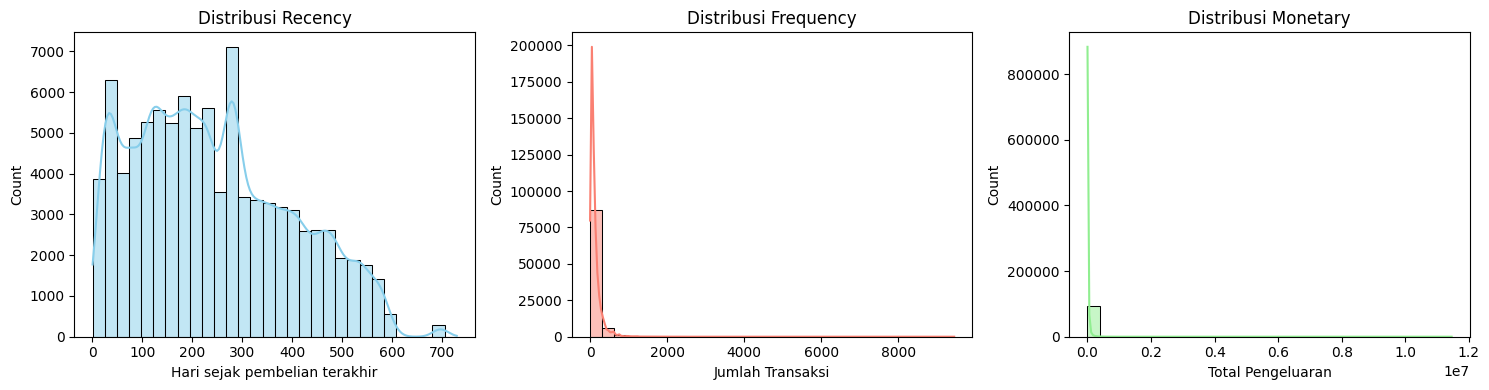

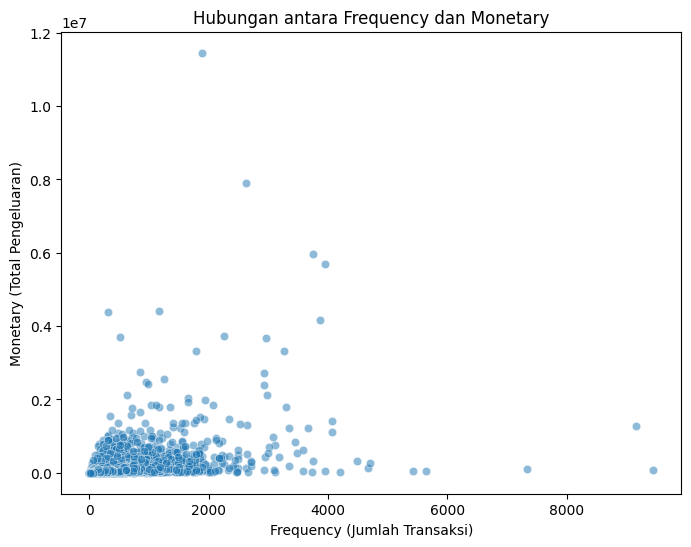

In [45]:
# Konversi kolom tanggal pembelian ke tipe datetime
data['order_purchase_timestamp'] = pd.to_datetime(data['order_purchase_timestamp'])

# Menetapkan snapshot_date (satu hari setelah pembelian terakhir) untuk perhitungan recency
snapshot_date = data['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

# Hitung nilai RFM untuk setiap pelanggan menggunakan 'customer_unique_id'
rfm = data.groupby('customer_unique_id').agg({
    'order_purchase_timestamp': lambda x: (snapshot_date - x.max()).days,  # Recency
    'order_id': 'count',   # Frequency
    'payment_value': 'sum' # Monetary
}).reset_index()

# Ubah nama kolom hasil agregasi agar lebih jelas
rfm.columns = ['customer_unique_id', 'Recency', 'Frequency', 'Monetary']

# Visualisasi distribusi masing-masing metrik RFM
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
sns.histplot(rfm['Recency'], kde=True, bins=30, color='skyblue')
plt.title('Distribusi Recency')
plt.xlabel('Hari sejak pembelian terakhir')

plt.subplot(1, 3, 2)
sns.histplot(rfm['Frequency'], kde=True, bins=30, color='salmon')
plt.title('Distribusi Frequency')
plt.xlabel('Jumlah Transaksi')

plt.subplot(1, 3, 3)
sns.histplot(rfm['Monetary'], kde=True, bins=30, color='lightgreen')
plt.title('Distribusi Monetary')
plt.xlabel('Total Pengeluaran')

plt.tight_layout()
plt.show()

# Scatter plot untuk melihat hubungan antara Frequency dan Monetary
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Frequency', y='Monetary', data=rfm, alpha=0.5)
plt.title('Hubungan antara Frequency dan Monetary')
plt.xlabel('Frequency (Jumlah Transaksi)')
plt.ylabel('Monetary (Total Pengeluaran)')
plt.show()



Berdasarkan hasil analisis, **analisis RFM (Recency, Frequency, Monetary)** menunjukkan bahwa mayoritas pelanggan memiliki Recency yang berada dalam rentang puluhan hingga ratusan hari, dengan Frequency yang umumnya rendah (1–2 transaksi) dan total pengeluaran (Monetary) yang relatif rendah. Namun, terdapat segelintir pelanggan yang memiliki Frequency tinggi dan outlier dengan pengeluaran sangat besar. Hasil ini diperoleh dengan mengelompokkan pelanggan berdasarkan tiga variabel kunci tersebut, yang kemudian divisualisasikan melalui scatter plot Frequency vs Monetary. Analisis ini memungkinkan kita mengidentifikasi segmen seperti pelanggan loyal, pelanggan berisiko, dan pelanggan yang perlu ditingkatkan retensinya.  

Mengapa informasi ini penting?  
- **Bagi Tim Pemasaran:** Memungkinkan penentuan strategi pemasaran yang lebih terfokus untuk masing-masing segmen pelanggan.  
- **Bagi Tim Retensi:** Membantu dalam mengidentifikasi pelanggan berisiko yang memerlukan perhatian khusus agar tidak berpindah ke kompetitor.  
- **Bagi Strategi Penjualan:** Mengoptimalkan penawaran produk dan layanan berdasarkan perilaku pembelian dan nilai transaksi pelanggan.


5. **Manual Grouping:**  
   Bagaimana cara mengelompokkan pelanggan berdasarkan jumlah transaksi dengan kriteria manual, misalnya mengkategorikan mereka ke dalam kelompok "Rendah", "Sedang", dan "Tinggi", serta apakah terdapat perbedaan signifikan pada total pengeluaran (Monetary) di masing-masing kelompok?

   - **Mengapa ini penting?**  
     - Memungkinkan identifikasi **segmentasi pelanggan** berdasarkan jumlah transaksi yang mereka lakukan.  
     - Berguna untuk strategi pemasaran yang lebih **terarah**, misalnya memberikan insentif khusus kepada pelanggan dengan transaksi tinggi.  
     - Membantu dalam **customer retention**, dengan memahami pola belanja pelanggan dan menargetkan mereka dengan promosi yang sesuai.  
     - Mengetahui apakah terdapat perbedaan signifikan pada total pengeluaran di tiap kelompok membantu dalam **menentukan strategi harga dan diskon** yang efektif.  


C:\Users\FX506\AppData\Local\Temp\ipykernel_36500\1740719536.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Transaksi_Group', y='Monetary', data=rfm, order=["Rendah", "Sedang", "Tinggi"], palette='Set2')


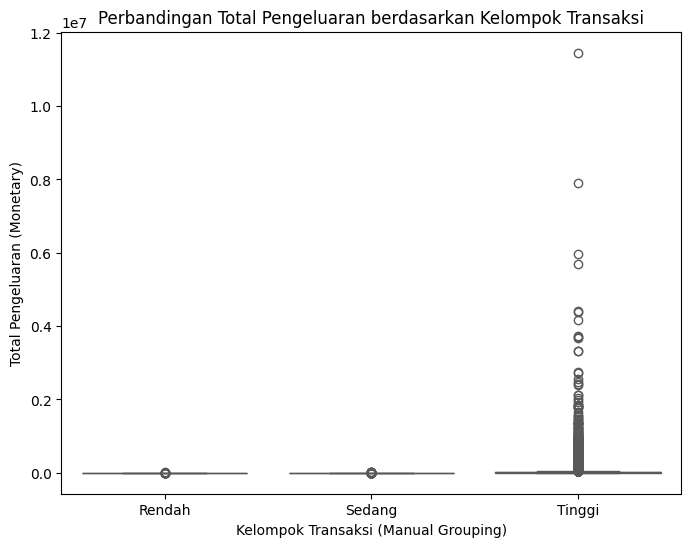

In [46]:
# --- 1. Clustering dengan Manual Grouping ---
# Definisikan kriteria manual untuk mengelompokkan pelanggan berdasarkan Frequency
def manual_grouping(freq):
    if freq <= 2:
        return "Rendah"
    elif freq <= 5:
        return "Sedang"
    else:
        return "Tinggi"

rfm['Transaksi_Group'] = rfm['Frequency'].apply(manual_grouping)

# Visualisasi perbedaan total pengeluaran di tiap kelompok
plt.figure(figsize=(8,6))
sns.boxplot(x='Transaksi_Group', y='Monetary', data=rfm, order=["Rendah", "Sedang", "Tinggi"], palette='Set2')
plt.title('Perbandingan Total Pengeluaran berdasarkan Kelompok Transaksi')
plt.xlabel('Kelompok Transaksi (Manual Grouping)')
plt.ylabel('Total Pengeluaran (Monetary)')
plt.show()


Pada pendekatan **manual grouping**, pelanggan dikelompokkan berdasarkan jumlah transaksi ke dalam tiga kategori: "Rendah" (≤ 2 transaksi), "Sedang" (3–5 transaksi), dan "Tinggi" (> 5 transaksi). Hasil visualisasi, seperti boxplot, menunjukkan bahwa pelanggan pada kelompok "Tinggi" umumnya memiliki total pengeluaran yang lebih besar, meskipun terdapat outlier yang sangat tinggi, sedangkan kelompok "Rendah" dan "Sedang" cenderung memiliki pengeluaran lebih rendah dan sebaran yang lebih sempit. Pengelompokan manual ini diperoleh dengan menetapkan ambang batas transaksi secara eksplisit dan memberikan gambaran jelas mengenai hubungan antara frekuensi transaksi dan nilai pengeluaran.

Mengapa informasi ini penting?  
- **Bagi Tim Pemasaran:** Memberikan dasar untuk segmentasi pelanggan secara manual sehingga promosi dan program loyalitas dapat disesuaikan dengan intensitas transaksi.  
- **Bagi Pengembangan Produk:** Menunjukkan potensi peningkatan penjualan dengan menargetkan pelanggan yang bertransaksi tinggi secara khusus.  
- **Bagi Manajemen Risiko:** Membantu mengidentifikasi segmen pelanggan dengan aktivitas transaksi rendah yang mungkin memerlukan intervensi untuk meningkatkan loyalitas.



6. **Binning:**  
   Bagaimana cara mengelompokkan pelanggan berdasarkan total pengeluaran (Monetary) dengan menggunakan teknik binning, misalnya 
   dengan membagi nilai pengeluaran ke dalam interval tertentu, dan bagaimana distribusi jumlah pelanggan di tiap bin tersebut?

   - **Mengapa ini penting?**  
     - Membantu dalam **klasifikasi pelanggan berdasarkan daya beli** mereka, yang dapat digunakan untuk strategi pemasaran dan personalisasi promosi.  
     - Dengan membagi pelanggan ke dalam kategori seperti **low spender, mid spender, dan high spender**, bisnis dapat **menyesuaikan strategi komunikasi dan penawaran produk**.  
     - Distribusi pelanggan di tiap bin menunjukkan apakah sebagian besar pelanggan berbelanja dalam jumlah kecil atau ada **segmen pelanggan premium yang membelanjakan lebih banyak**.  
     - Dapat digunakan untuk **perencanaan diskon dan program loyalitas** berdasarkan tingkat pengeluaran pelanggan.  

C:\Users\FX506\AppData\Local\Temp\ipykernel_36500\3547302229.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=monetary_distribution.index, y=monetary_distribution.values, palette='Blues_d')


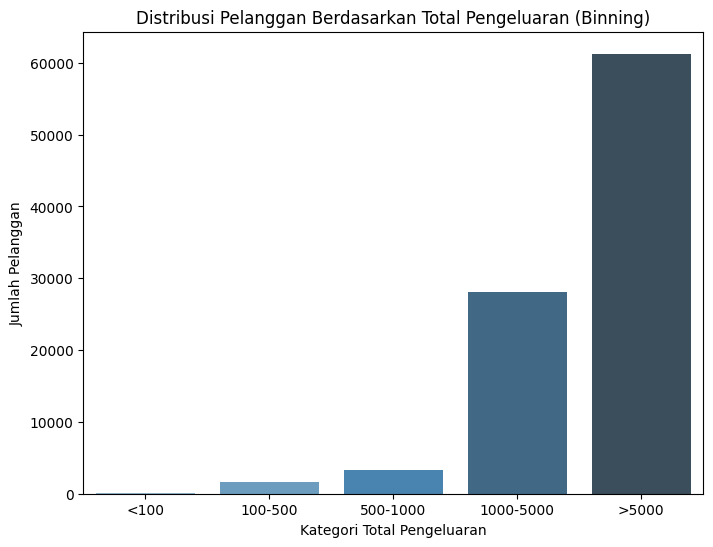

In [47]:
# --- 2. Clustering dengan Teknik Binning ---
# Tentukan bins untuk total pengeluaran. Bins ini bisa disesuaikan dengan karakteristik data.
bins = [0, 100, 500, 1000, 5000, rfm['Monetary'].max()]
labels = ['<100', '100-500', '500-1000', '1000-5000', '>5000']
rfm['Monetary_bin'] = pd.cut(rfm['Monetary'], bins=bins, labels=labels, include_lowest=True)

# Hitung jumlah pelanggan di tiap bin
monetary_distribution = rfm['Monetary_bin'].value_counts().sort_index()

# Visualisasi distribusi pelanggan berdasarkan bin total pengeluaran
plt.figure(figsize=(8,6))
sns.barplot(x=monetary_distribution.index, y=monetary_distribution.values, palette='Blues_d')
plt.title('Distribusi Pelanggan Berdasarkan Total Pengeluaran (Binning)')
plt.xlabel('Kategori Total Pengeluaran')
plt.ylabel('Jumlah Pelanggan')
plt.show()


Sedangkan pada pendekatan **binning**, total pengeluaran (Monetary) pelanggan dibagi ke dalam beberapa interval, misalnya: <100, 100–500, 500–1000, 1000–5000, dan >5000. Teknik ini, yang diterapkan dengan menggunakan `pd.cut`, mengungkapkan bahwa mayoritas pelanggan masuk ke dalam kategori pengeluaran >5000, sementara kategori dengan pengeluaran lebih rendah diwakili oleh jumlah pelanggan yang lebih sedikit. Pembagian interval ini memberikan pemahaman mendalam mengenai distribusi daya beli pelanggan dan variasi nilai transaksi mereka.

Mengapa informasi ini penting?  
- **Bagi Strategi Pemasaran:** Memungkinkan pembuatan kampanye yang lebih spesifik berdasarkan kelompok daya beli, sehingga penawaran produk dapat disesuaikan dengan kemampuan pengeluaran pelanggan.  
- **Bagi Penentuan Harga:** Menjadi dasar untuk penetapan strategi harga yang dinamis sesuai dengan segmen pengeluaran.  
- **Bagi Analisis Pasar:** Memberikan wawasan tentang sebaran pelanggan berdasarkan nilai transaksi, yang sangat berguna untuk perencanaan keuangan dan pengelolaan stok secara lebih efisien.

## Conclusion

**Berdasarkan analisis dataset yang telah dilakukan, dapat disimpulkan beberapa hal utama berikut:**

1. **Distribusi Skor Review dan Dampaknya Terhadap Penjualan**  
   Produk dengan skor review tinggi (4–5) menunjukkan performa penjualan yang jauh lebih baik, dengan total penjualan mencapai 10.659.278 unit, dibandingkan dengan produk ber-skor rendah (1–2) yang hanya mencapai 2.854.572 unit. Hal ini menegaskan bahwa review positif sangat berpengaruh dalam keputusan pembelian pelanggan. Oleh karena itu, menjaga kualitas produk dan layanan agar mendapatkan ulasan yang baik merupakan strategi krusial untuk meningkatkan penjualan.

2. **Kategori Produk dan Metode Pembayaran yang Diminati**  
   Dari segi kategori, pelanggan paling banyak memilih produk yang berkaitan dengan kebutuhan rumah tangga, kecantikan, dan teknologi serta hiburan. Kategori **cama_mesa_banho** menempati posisi teratas, diikuti oleh **beleza_saude**, **moveis_decoracao**, **esporte_lazer**, **informatica_acessorios**, dan **utilidades_domesticas**.  
   Sedangkan dari analisis metode pembayaran, **kartu kredit** mendominasi dengan persentase 73.6%, menunjukkan preferensi pelanggan terhadap metode pembayaran yang menawarkan fleksibilitas, seperti cicilan. Informasi ini bisa dimanfaatkan bisnis untuk mengembangkan program promosi atau insentif khusus bagi pengguna kartu kredit.

3. **Distribusi Geografis Penjual dan Pelanggan**  
   Analisis geografis mengungkapkan bahwa **São Paulo** merupakan pusat utama e-commerce, dengan jumlah penjual terbanyak (694 penjual) dan pelanggan terbanyak (14.757 pelanggan). Wilayah ini menunjukkan aktivitas perdagangan online yang sangat tinggi, sehingga strategi pemasaran, distribusi, serta pengelolaan logistik sebaiknya difokuskan di sini untuk memaksimalkan potensi pasar.

4. **Analisis RFM (Recency, Frequency, Monetary)**  
   Berdasarkan analisis RFM, kita dapat mengelompokkan pelanggan dengan memperhatikan seberapa baru mereka terakhir bertransaksi (Recency), seberapa sering mereka bertransaksi (Frequency), dan seberapa besar total pengeluaran mereka (Monetary). Hasil distribusi menunjukkan bahwa mayoritas pelanggan memiliki Recency di rentang puluhan hingga ratusan hari, dengan Frequency cenderung rendah (umumnya 1–2 transaksi) namun terdapat segelintir pelanggan yang jauh lebih sering bertransaksi. Monetary sebagian besar juga relatif rendah, namun ada beberapa outlier dengan total pengeluaran sangat tinggi. Scatter plot Frequency vs Monetary memperlihatkan bahwa semakin sering pelanggan bertransaksi, umumnya semakin besar pula total pengeluarannya, meskipun ada sedikit pelanggan yang jarang bertransaksi namun tetap membelanjakan jumlah cukup besar. Temuan ini dapat membantu dalam segmentasi pelanggan, seperti mengidentifikasi pelanggan loyal, pelanggan berisiko, hingga pelanggan yang perlu ditingkatkan retensinya.

5. **Manual Grouping (Jumlah Transaksi)**  
   Pada pendekatan manual grouping ini, pelanggan dikelompokkan berdasarkan jumlah transaksi menjadi tiga kategori: "Rendah" (≤ 2 transaksi), "Sedang" (3–5 transaksi), dan "Tinggi" (> 5 transaksi). Hasil visualisasi boxplot menunjukkan bahwa kelompok "Tinggi" umumnya memiliki total pengeluaran (Monetary) yang lebih besar, meskipun terdapat outlier yang sangat tinggi. Sementara itu, kelompok "Rendah" dan "Sedang" cenderung memiliki pengeluaran lebih rendah dan sebaran yang lebih sempit. Hal ini mengindikasikan bahwa semakin sering pelanggan bertransaksi, kecenderungan total pengeluarannya juga meningkat.

6. **Binning (Total Pengeluaran)**  
   Pada pendekatan binning, total pengeluaran (Monetary) dibagi ke dalam beberapa interval, misalnya <100, 100–500, 500–1000, 1000–5000, dan >5000. Setelah melakukan pemotongan nilai ini menggunakan `pd.cut`, tampak bahwa mayoritas pelanggan masuk ke dalam kategori dengan pengeluaran >5000, sedangkan kategori dengan pengeluaran lebih rendah diisi oleh lebih sedikit pelanggan. Hal ini membantu memahami sebaran pelanggan berdasarkan nilai pengeluarannya, sehingga dapat ditindaklanjuti dengan strategi pemasaran yang lebih tepat untuk setiap kategori.

**Secara keseluruhan, hasil analisis ini tidak hanya mengkonfirmasi bahwa review positif mempengaruhi keputusan pembelian, tetapi juga mengidentifikasi kategori produk dan metode pembayaran yang paling diminati, potensi geografis utama dalam e-commerce, serta memberikan wawasan lebih lanjut mengenai perilaku pelanggan melalui analisis RFM, manual grouping, dan binning. Temuan ini menjadi landasan penting bagi pelaku bisnis dalam mengoptimalkan strategi pemasaran, meningkatkan kualitas produk dan layanan, serta mengelola stok dan distribusi secara lebih efisien.**